In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# ---------------------------------------------------------
# 1. Definir la distribución bivariada P(x, y)
# ---------------------------------------------------------
mean = [0, 0]
cov = [[2.0, 1.3],
       [1.3, 1.0]]
rv = multivariate_normal(mean, cov)

x, y = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-4, 4, 300))
pos = np.dstack((x, y))
z = rv.pdf(pos)

# ---------------------------------------------------------
# 2. Simular una nueva trayectoria de Gibbs sampling
#    (más pasos, otro punto de partida y otra semilla)
# ---------------------------------------------------------
np.random.seed(21)
n_steps = 11
current = np.array([3.3, -2.8])
trajectory = [current.copy()]

for i in range(n_steps):
    if i % 2 == 0:
        # Actualizar x | y  (paso horizontal)
        cond_mean = mean[0] + cov[0][1] / cov[1][1] * (current[1] - mean[1])
        cond_var = cov[0][0] - cov[0][1] ** 2 / cov[1][1]
        current = np.array([np.random.normal(cond_mean, np.sqrt(cond_var)), current[1]])
    else:
        # Actualizar y | x  (paso vertical)
        cond_mean = mean[1] + cov[1][0] / cov[0][0] * (current[0] - mean[0])
        cond_var = cov[1][1] - cov[1][0] ** 2 / cov[0][0]
        current = np.array([current[0], np.random.normal(cond_mean, np.sqrt(cond_var))])
    trajectory.append(current.copy())

trajectory = np.array(trajectory)

# ---------------------------------------------------------
# 3a. Gráfico 1: SOLO la distribución P(x,y)
# ---------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(5.5, 5.2))

ax1.contour(x, y, z, levels=6, colors='#0F6E56', linewidths=1.4)
ax1.axhline(0, color='gray', linewidth=0.7, zorder=0)
ax1.axvline(0, color='gray', linewidth=0.7, zorder=0)
ax1.text(2.6, 3.1, r'$P(x,y)$', fontsize=16, color='#0F6E56')

ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_xlim(-4, 4)
ax1.set_ylim(-4, 4)
ax1.set_aspect('equal')
ax1.set_title('Distribución conjunta P(x, y)', fontsize=12)

plt.tight_layout()
plt.savefig('01_distribucion_2d.png', dpi=220)
plt.close(fig1)

# ---------------------------------------------------------
# 3b. Gráfico 2: distribución + trayectoria de Gibbs
# ---------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(5.5, 5.2))

ax2.contour(x, y, z, levels=6, colors='#0F6E56', linewidths=1.0, alpha=0.6)

ax2.plot(trajectory[:, 0], trajectory[:, 1],
         '-o', color='#993C1D', markersize=5, linewidth=1.3,
         label='Trayectoria de Gibbs sampling')

ax2.plot(trajectory[0, 0], trajectory[0, 1], 'o',
          color='#993C1D', markersize=9, markerfacecolor='white',
          markeredgewidth=2, zorder=5, label='Punto inicial')

ax2.plot(trajectory[-1, 0], trajectory[-1, 1], '*',
          color='#993C1D', markersize=16, zorder=5, label='Punto final')

ax2.axhline(0, color='gray', linewidth=0.7, zorder=0)
ax2.axvline(0, color='gray', linewidth=0.7, zorder=0)

ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_xlim(-4, 4)
ax2.set_ylim(-4, 4)
ax2.set_aspect('equal')
ax2.legend(loc='lower left', frameon=False, fontsize=8.5)
ax2.set_title('Trayectoria de Gibbs sampling', fontsize=12)

plt.tight_layout()
plt.savefig('02_trayectoria_gibbs.png', dpi=220)
plt.close(fig2)

print("Listo")

Listo


In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

In [7]:
# ---------------------------------------------------------
# Datos: las 4 correspondencias
# ---------------------------------------------------------
pairs = [
    ("Energía " + r"$E(\mu)$", "Costo de un dato"),
    ("Distribución de Boltzmann", "Modelo probabilístico"),
    ("Función de partición " + r"$Z$", "Normalización"),
    ("Acoplamientos " + r"$J_{ij}$", "Pesos aprendibles " + r"$w_{ij}$"),
]

n = len(pairs)
box_w = 3.4
box_h = 0.9
gap_y = 1.35
x_left = 0.3
x_right = 5.6
fig_h = n * gap_y + 1.6

color_left = "#185FA5"      # azul (física)
color_left_fill = "#E6F1FB"
color_right = "#0F6E56"     # teal (IA)
color_right_fill = "#E1F5EE"

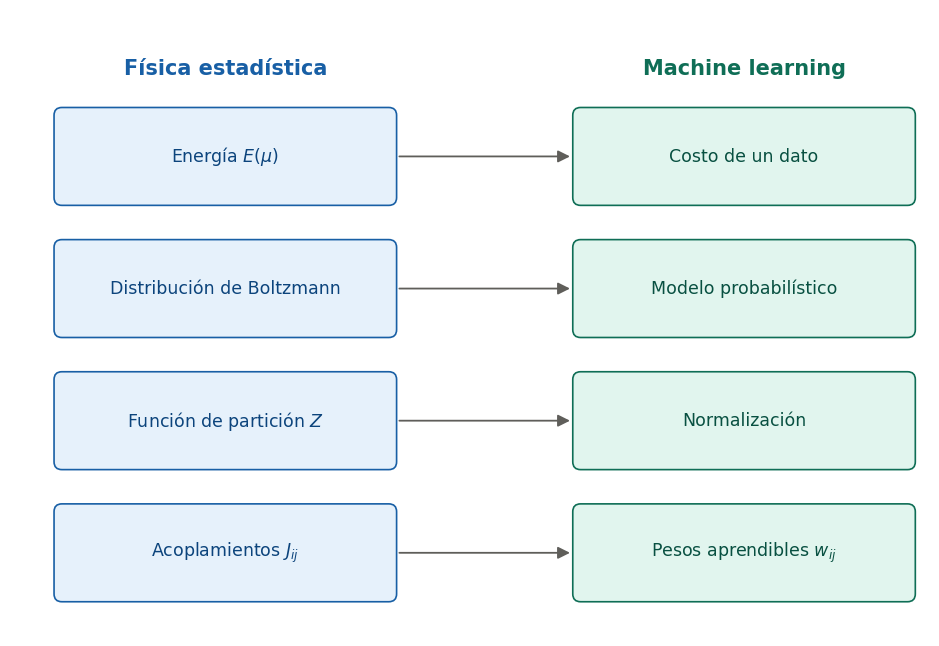

In [8]:
fig, ax = plt.subplots(figsize=(9.5, fig_h))

# Encabezados de columna
y_top = n * gap_y + 0.3
ax.text(x_left + box_w / 2, y_top, "Física estadística",
        ha="center", va="center", fontsize=15, fontweight="bold", color=color_left)
ax.text(x_right + box_w / 2, y_top, "Machine learning",
        ha="center", va="center", fontsize=15, fontweight="bold", color=color_right)

# Cajas y flechas para cada correspondencia
for i, (left_text, right_text) in enumerate(pairs):
    y = (n - 1 - i) * gap_y + 0.3

    box_left = FancyBboxPatch(
        (x_left, y), box_w, box_h,
        boxstyle="round,pad=0.05,rounding_size=0.08",
        linewidth=1.2, edgecolor=color_left, facecolor=color_left_fill
    )
    ax.add_patch(box_left)
    ax.text(x_left + box_w / 2, y + box_h / 2, left_text,
            ha="center", va="center", fontsize=12.5, color="#0C447C")

    box_right = FancyBboxPatch(
        (x_right, y), box_w, box_h,
        boxstyle="round,pad=0.05,rounding_size=0.08",
        linewidth=1.2, edgecolor=color_right, facecolor=color_right_fill
    )
    ax.add_patch(box_right)
    ax.text(x_right + box_w / 2, y + box_h / 2, right_text,
            ha="center", va="center", fontsize=12.5, color="#085041")

    arrow = FancyArrowPatch(
        (x_left + box_w + 0.05, y + box_h / 2),
        (x_right - 0.05, y + box_h / 2),
        arrowstyle="-|>", mutation_scale=18,
        linewidth=1.3, color="#5F5E5A"
    )
    ax.add_patch(arrow)

ax.set_xlim(-0.2, x_right + box_w + 0.2)
ax.set_ylim(-0.1, y_top + 0.6)
ax.axis("off")
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("diccionario_fisica_ia.png", dpi=220, bbox_inches="tight")
plt.show()

Listo


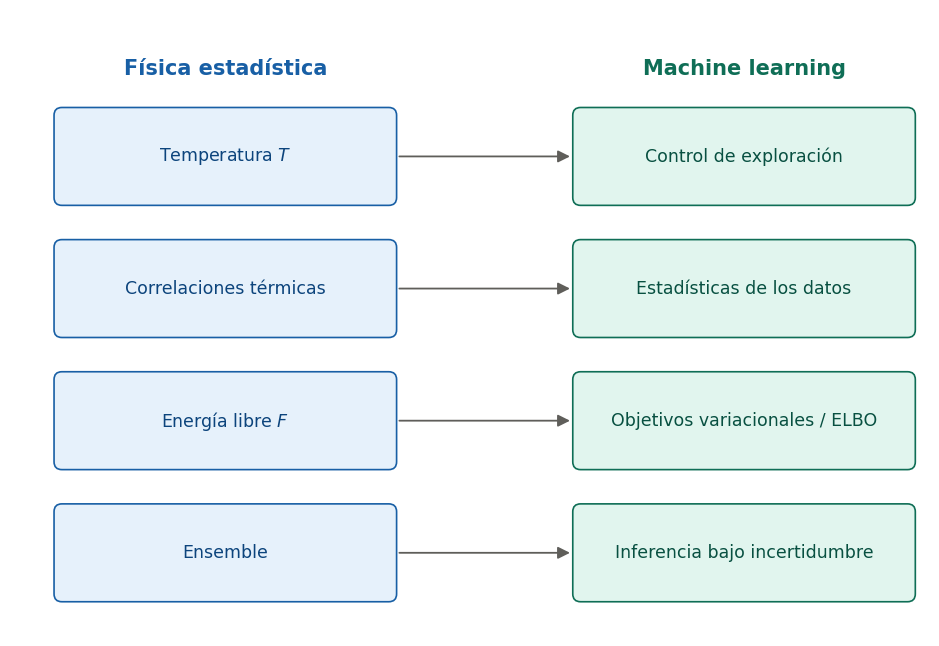

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ---------------------------------------------------------
# Datos: las 4 correspondencias restantes
# ---------------------------------------------------------
pairs = [
    ("Temperatura " + r"$T$", "Control de exploración"),
    ("Correlaciones térmicas", "Estadísticas de los datos"),
    ("Energía libre " + r"$F$", "Objetivos variacionales / ELBO"),
    ("Ensemble", "Inferencia bajo incertidumbre"),
]

n = len(pairs)
box_w = 3.4
box_h = 0.9
gap_y = 1.35
x_left = 0.3
x_right = 5.6
fig_h = n * gap_y + 1.6

color_left = "#185FA5"      # azul (física)
color_left_fill = "#E6F1FB"
color_right = "#0F6E56"     # teal (IA)
color_right_fill = "#E1F5EE"

fig, ax = plt.subplots(figsize=(9.5, fig_h))

# Encabezados de columna
y_top = n * gap_y + 0.3
ax.text(x_left + box_w / 2, y_top, "Física estadística",
        ha="center", va="center", fontsize=15, fontweight="bold", color=color_left)
ax.text(x_right + box_w / 2, y_top, "Machine learning",
        ha="center", va="center", fontsize=15, fontweight="bold", color=color_right)

# Cajas y flechas para cada correspondencia
for i, (left_text, right_text) in enumerate(pairs):
    y = (n - 1 - i) * gap_y + 0.3

    box_left = FancyBboxPatch(
        (x_left, y), box_w, box_h,
        boxstyle="round,pad=0.05,rounding_size=0.08",
        linewidth=1.2, edgecolor=color_left, facecolor=color_left_fill
    )
    ax.add_patch(box_left)
    ax.text(x_left + box_w / 2, y + box_h / 2, left_text,
            ha="center", va="center", fontsize=12.5, color="#0C447C")

    box_right = FancyBboxPatch(
        (x_right, y), box_w, box_h,
        boxstyle="round,pad=0.05,rounding_size=0.08",
        linewidth=1.2, edgecolor=color_right, facecolor=color_right_fill
    )
    ax.add_patch(box_right)
    ax.text(x_right + box_w / 2, y + box_h / 2, right_text,
            ha="center", va="center", fontsize=12.5, color="#085041")

    arrow = FancyArrowPatch(
        (x_left + box_w + 0.05, y + box_h / 2),
        (x_right - 0.05, y + box_h / 2),
        arrowstyle="-|>", mutation_scale=18,
        linewidth=1.3, color="#5F5E5A"
    )
    ax.add_patch(arrow)

ax.set_xlim(-0.2, x_right + box_w + 0.2)
ax.set_ylim(-0.1, y_top + 0.6)
ax.axis("off")
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig('diccionario_fisica_ia_2.png', dpi=220, bbox_inches="tight")
print("Listo")